#**Computer Vision for Developers with Ultralytics — SDAIA Academy**

**🧠 Brain-Tumor Detection & Automated tumor counting on MRI scans. — YOLO11 Capstone**

##**Setup**


In [1]:
%pip install -q -U ultralytics onnx onnxruntime

import ultralytics, torch
ultralytics.checks()
print("Torch CUDA available:", torch.cuda.is_available())
print("Device:", "GPU (T4)" if torch.cuda.is_available() else "CPU  ⚠️  T4 GPU - Runtime")

Ultralytics 8.4.118 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.1/112.6 GB disk)
Torch CUDA available: True
Device: GPU (T4)


##  Custom Data & Training


In [2]:
from ultralytics import YOLO

train_model = YOLO("yolo11n.pt")

train_results = train_model.train(
    data="brain-tumor.yaml",
    epochs=30,
    imgsz=640,
    batch=16,
    patience=15,
    seed=0,
    plots=True,
    project="runs",
    name="brain_tumor_yolo11n",
    exist_ok=True,
)

from pathlib import Path
run_dir  = Path(train_results.save_dir)
best_pt  = run_dir / "weights" / "best.pt"
print("Training finished. Best weights:", best_pt)

Ultralytics 8.4.118 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=brain-tumor.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=brain_tumor_yolo11n, nbs=64, nms=False, opset=

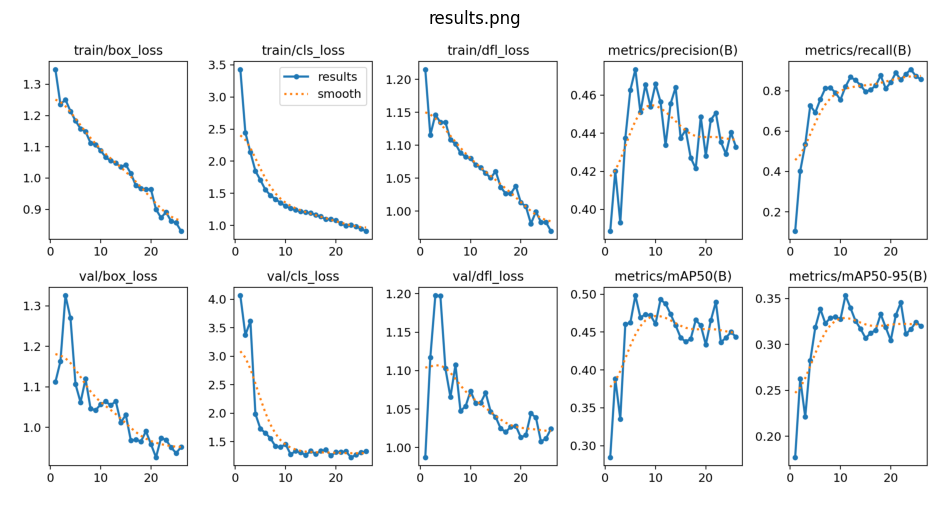

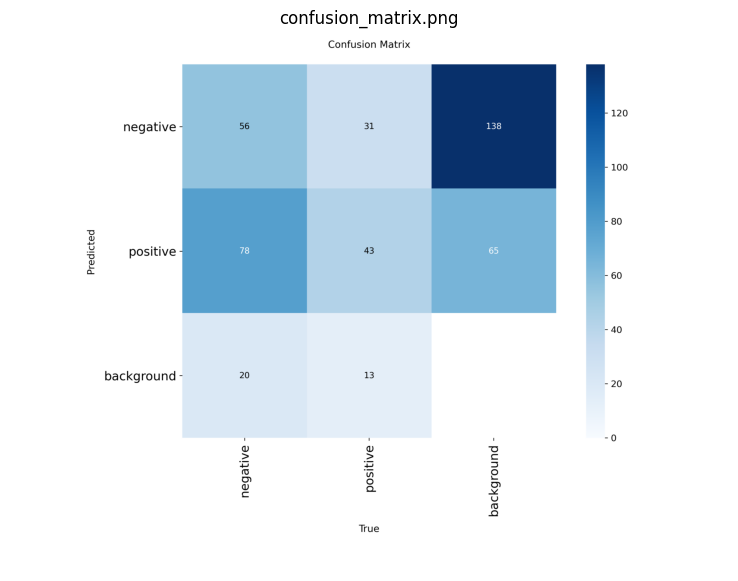

In [3]:
# Display training curves + confusion matrix (execution evidence; check over/underfitting)
import matplotlib.pyplot as plt

for img_name in ["results.png", "confusion_matrix.png"]:
    p = run_dir / img_name
    if p.exists():
        plt.figure(figsize=(12, 7))
        plt.imshow(plt.imread(str(p))); plt.axis("off")
        plt.title(img_name); plt.show()
    else:
        print("Not found:", p)

**Reading the result (over/underfitting):** All `train/*_loss` curves keep decreasing steadily through epoch 26 without flattening, and `val/*_loss` also trends down (after early noise) rather than rising — so there is no overfitting; if anything the model is slightly underfitting and could still improve with more training. Early-stopping halted at epoch 26. Accuracy is modest and expected: `yolo11n` is small and the dataset is limited. To improve it I would train longer or move to a larger model (`yolo11s`) with stronger augmentation.

##  Core Vision Tasks & Inference

Running inference on MRI scans:
- **Detection** — the trained `best.pt` draws boxes around tumors (finds *where* they are).
- **Instance Segmentation** (a task beyond detection) — `yolo11n-seg.pt` outlines objects pixel-by-pixel, not just boxes. It's a general (non-medical) model, so `Masks found: 0` on MRI is expected; the point is to show the segmentation task runs.

In [4]:
import glob, os


try:
    from ultralytics.data.utils import check_det_dataset
    dd = check_det_dataset("brain-tumor.yaml")
    vp = dd["val"]
    vp = vp[0] if isinstance(vp, (list, tuple)) else vp
    vp = Path(vp)
    if vp.is_file():
        mri_images = [l.strip() for l in open(vp) if l.strip()]
    else:
        mri_images = sorted(glob.glob(str(vp / "*.jpg")) + glob.glob(str(vp / "*.png")))
except Exception as e:
    print("path lookup fell back to glob:", e)
    mri_images = sorted(g for g in glob.glob("/content/datasets/brain-tumor/**/*.jpg",
                                             recursive=True) if "val" in g.lower())

print("Found", len(mri_images), "validation MRI scans")
sample_img = mri_images[0]
print("Sample:", sample_img)

Found 223 validation MRI scans
Sample: /content/datasets/brain-tumor/images/val/val_1 (1).jpg



image 1/1 /content/datasets/brain-tumor/images/val/val_1 (1).jpg: 640x640 2 negatives, 9.3ms
Speed: 2.5ms preprocess, 9.3ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict
Tumor detections in this scan: 2
  - negative   conf=0.52
  - negative   conf=0.26


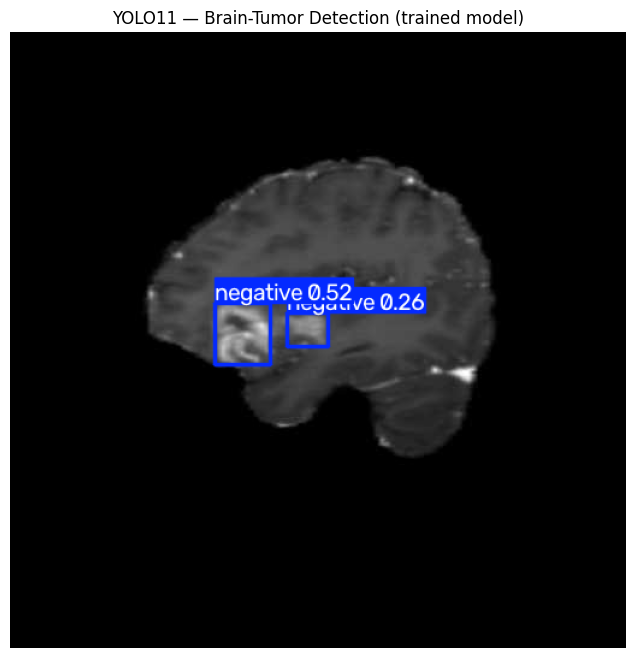

In [5]:
# --- Detection with the trained brain-tumor model ---
det_model = YOLO(str(best_pt))
det_res = det_model.predict(source=sample_img, save=True, conf=0.25, imgsz=640)
dr = det_res[0]

print("Tumor detections in this scan:", 0 if dr.boxes is None else len(dr.boxes))
for b in (dr.boxes or []):
    print(f"  - {det_model.names[int(b.cls)]:10s} conf={float(b.conf):.2f}")

plt.figure(figsize=(8, 8))
plt.imshow(dr.plot()[..., ::-1])   # BGR -> RGB
plt.axis("off"); plt.title("YOLO11 — Brain-Tumor Detection (trained model)"); plt.show()


image 1/1 /content/datasets/brain-tumor/images/val/val_1 (1).jpg: 640x640 (no detections), 43.9ms
Speed: 4.0ms preprocess, 43.9ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/segment/predict
Segmentation task ran. Masks found: 0


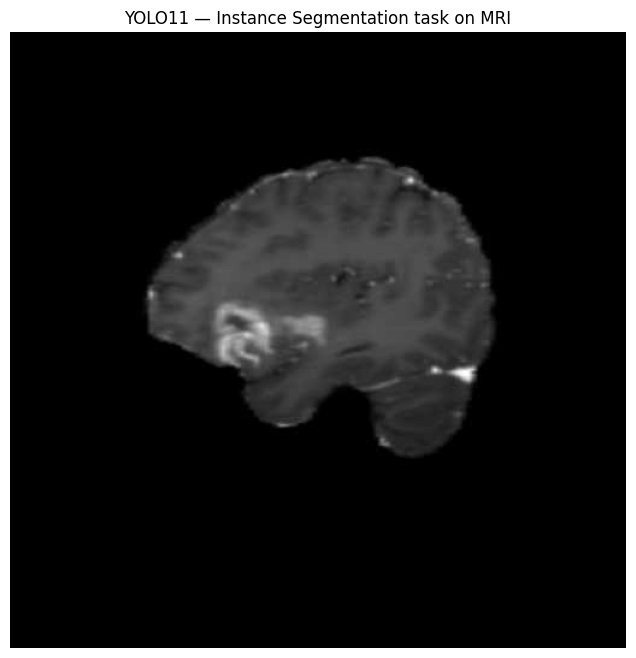

In [6]:
## --- Instance Segmentation: a task beyond detection (task-specific weights) ---
seg_model = YOLO("yolo11n-seg.pt")
seg_res = seg_model.predict(source=sample_img, save=True, imgsz=640)
sr = seg_res[0]

print("Segmentation task ran. Masks found:", 0 if sr.masks is None else len(sr.masks))
plt.figure(figsize=(8, 8))
plt.imshow(sr.plot()[..., ::-1])
plt.axis("off"); plt.title("YOLO11 — Instance Segmentation task on MRI"); plt.show()

##  Real-World Solution & Video Analytics

Automated Screening: a real OpenCV pipeline runs model.track over an MRI image stream, writing an output video and counting tumors per scan and overall.


Screened 40 MRI scans
Scans flagged (>=1 detection): 38
Total tumor detections across the stream: 63
Saved annotated screening video -> screening_stream.mp4


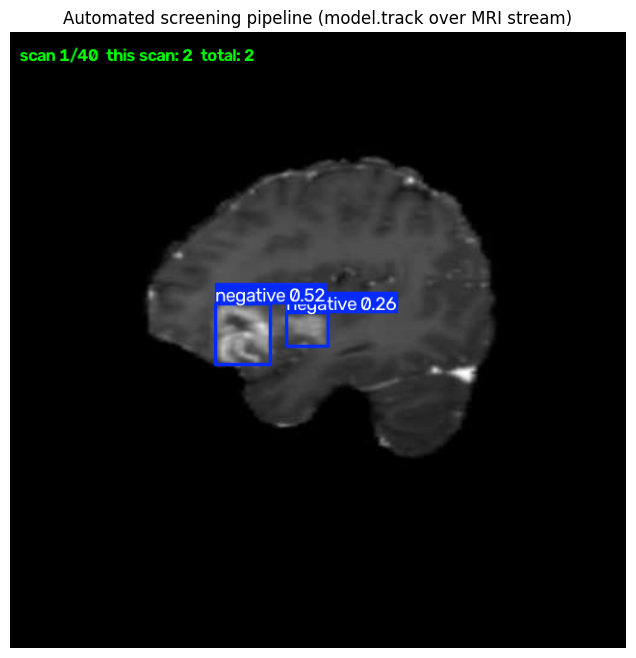

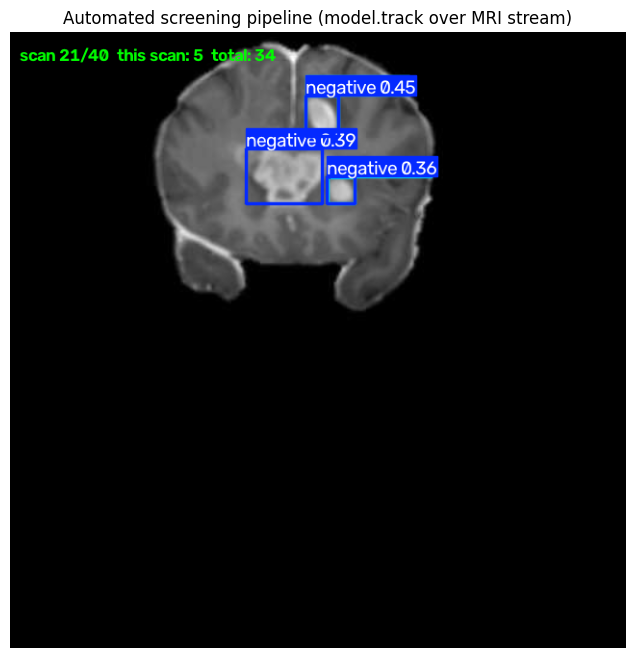

In [12]:
import cv2

SIZE = 640
FPS  = 5
stream = mri_images[:40]

screener = YOLO(str(best_pt))
writer = cv2.VideoWriter("screening_stream.mp4",
                         cv2.VideoWriter_fourcc(*"mp4v"), FPS, (SIZE, SIZE))

per_scan_counts, total_detections, samples = [], 0, []
for idx, ip in enumerate(stream):
    img = cv2.imread(ip)
    if img is None:
        continue
    img = cv2.resize(img, (SIZE, SIZE))
    res = screener.track(img, persist=True, conf=0.25, verbose=False)
    n = 0 if res[0].boxes is None else len(res[0].boxes)
    per_scan_counts.append(n); total_detections += n

    annotated = res[0].plot()
    cv2.putText(annotated,
                f"scan {idx+1}/{len(stream)}  this scan: {n}  total: {total_detections}",
                (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
    writer.write(annotated)
    if idx in (0, len(stream) // 2):
        samples.append(annotated.copy())

writer.release()
flagged = sum(1 for c in per_scan_counts if c > 0)
print(f"Screened {len(per_scan_counts)} MRI scans")
print(f"Scans flagged (>=1 detection): {flagged}")
print(f"Total tumor detections across the stream: {total_detections}")
print("Saved annotated screening video -> screening_stream.mp4")

# عرض عيّنة إطارات inline
for s in samples:
    plt.figure(figsize=(8, 8))
    plt.imshow(s[..., ::-1]); plt.axis("off")
    plt.title("Automated screening pipeline (model.track over MRI stream)"); plt.show()

In [13]:
import subprocess, os
from IPython.display import HTML
from base64 import b64encode


subprocess.run(
    ["ffmpeg", "-y", "-i", "screening_stream.mp4",
     "-vcodec", "libx264", "-pix_fmt", "yuv420p", "screening_play.mp4"],
    capture_output=True
)

show = "screening_play.mp4" if os.path.exists("screening_play.mp4") else "screening_stream.mp4"
mp4 = open(show, "rb").read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
HTML(f'<video width=500 controls><source src="{data_url}" type="video/mp4"></video>')

##  Model Evaluation



In [8]:
best = YOLO(str(best_pt))
metrics = best.val(data="brain-tumor.yaml", imgsz=640, conf=0.25, iou=0.6, plots=True)

print("=== Validation metrics (Brain-Tumor) ===")
print(f"mAP50-95 : {float(metrics.box.map):.4f}")
print(f"mAP50    : {float(metrics.box.map50):.4f}")
print(f"mAP75    : {float(metrics.box.map75):.4f}")
print(f"Precision: {float(metrics.box.mp):.4f}")
print(f"Recall   : {float(metrics.box.mr):.4f}")

Ultralytics 8.4.118 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,542 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 142.2±78.0 MB/s, size: 3.1 KB)
val: Scanning /content/datasets/brain-tumor/labels/val.cache... 223 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 223/223 62.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 14/14 2.7it/s 5.1s
                   all        223        241      0.474        0.8      0.438      0.322
              negative        142        154      0.605      0.864      0.565      0.405
              positive         81         87      0.344      0.736      0.311      0.238
Speed: 4.5ms preprocess, 6.0ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to /content/runs/detect/val
=== Validation metrics (Brain-Tumor) ===
mAP50-95 : 0.3215
mAP50    : 0.4381
mAP75    : 0.3

### Interpretation (medical context)


- **mAP50 / mAP50-95** — detection accuracy at IoU 0.50, and averaged over IoU 0.50–0.95 (stricter, penalizes loose tumor localization).
- **Precision (0.47)** — of all "tumor" predictions, how many were correct. Low precision means **false positives (FP)** — extra alarms.
- **Recall (0.80)** — of all real tumors, how many the model caught. Low recall means **false negatives (FN)** — missed tumors.
- **In medical screening, a false negative (missing a tumor) is far more costly than a false positive** (an extra alarm a radiologist reviews). Our model already favors this trade-off: **Recall (0.80) > Precision (0.47)** — it is sensitive and catches most tumors at the cost of some false alarms, which is the right balance for a triage system. To push sensitivity further, lower the `conf` threshold (e.g. 0.15 instead of 0.25) with expert review of uncertain cases.
- **Confusion Matrix** — off-diagonal cells are errors. Most confusion is in the `positive` class (real tumors predicted as background), i.e. the **FN** we most want to reduce.
- **IoU = 0.6** was chosen for validation as a balance: high enough to require good localization, not so strict that minor box differences are penalized.

##  Deployment & Export

Export the trained model to **ONNX** and verify it runs with `onnxruntime`. ONNX is portable and runs on CPU without PyTorch/GPU.

In [9]:
onnx_path = best.export(format="onnx", imgsz=640, opset=12)
print("Exported ONNX model ->", onnx_path)

import onnxruntime as ort
sess = ort.InferenceSession(onnx_path, providers=["CPUExecutionProvider"])
print("ONNX runtime session OK")
print("Inputs :", [i.name for i in sess.get_inputs()])
print("Outputs:", [o.name for o in sess.get_outputs()])

Ultralytics 8.4.118 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/content/runs/detect/runs/brain_tumor_yolo11n/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 6, 8400) (5.2 MB)
requirements: Ultralytics requirement ['onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 10 packages in 317ms
Prepared 2 packages in 42ms
Installed 2 packages in 5ms
 + colorama==0.4.6
 + onnxslim==0.1.95

requirements: AutoUpdate success ✅ 0.5s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.22.0 opset 12...
ONNX: slimming with onnxslim 0.1.95...
ONNX: export success ✅ 2.1s, saved as '/content/runs/detect/runs/brain_tumor_yolo11n/weights/best.onnx' (10.1 MB)

Export 